In [32]:
!pip -q install opencv-python numpy matplotlib

In [33]:
import zipfile
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

IMG2_PATH = Path('/content/Checkerboard_Images/Image2.tif')
IMG9_PATH = IMG2_PATH.parent / 'Image9.tif'

if not IMG2_PATH.exists():
    from google.colab import drive
    drive.mount('/content/drive')
    roots = [p for p in Path('/content/drive/MyDrive').iterdir() if p.is_dir()]
    sid = Path('/content/drive/.shortcut-targets-by-id/1fUo6TQmvkCPWg9MVaEQTyx3tOZ0yTEkG')
    if sid.exists():
        roots.append(sid)
    z = next((p for r in roots for p in r.rglob('Checkerboard_Images.zip')), None)
    if not z:
        raise FileNotFoundError('Checkerboard_Images.zip not found')
    zipfile.ZipFile(z).extractall('/content')

In [34]:
def detect_checkerboard_corners(image_path, pattern_size=(6, 5)):
    """Return (N, 2) pixel coordinates of inner chessboard corners."""
    img = cv2.imread(str(image_path))
    if img is None:
        raise FileNotFoundError(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    flags = cv2.CALIB_CB_ADAPTIVE_THRESH | cv2.CALIB_CB_NORMALIZE_IMAGE
    ok, corners = cv2.findChessboardCorners(gray, pattern_size, flags)

    # These TIF images often fail the classic detector; SB is still OpenCV chessboard corners.
    if not ok and hasattr(cv2, 'findChessboardCornersSB'):
        ok, corners = cv2.findChessboardCornersSB(gray, pattern_size, None)

    if not ok:
        raise RuntimeError(
            f'Chessboard not found in {image_path} with pattern_size={pattern_size}'
        )

    corners = cv2.cornerSubPix(
        gray, corners, (11, 11), (-1, -1),
        criteria=(cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001),
    )
    return corners.reshape(-1, 2), img


def _normalize_points(pts):
    """Similarity-normalize 2D points for numerically stable DLT."""
    centroid = np.mean(pts, axis=0)
    shifted = pts - centroid
    mean_dist = np.mean(np.sqrt(np.sum(shifted**2, axis=1)))
    if mean_dist < 1e-12:
        raise ValueError('Degenerate points: all points are identical')

    scale = np.sqrt(2.0) / mean_dist
    T = np.array([
        [scale, 0.0, -scale * centroid[0]],
        [0.0, scale, -scale * centroid[1]],
        [0.0, 0.0, 1.0],
    ], dtype=np.float64)

    pts_h = np.hstack([pts, np.ones((len(pts), 1))])
    pts_n_h = (T @ pts_h.T).T
    pts_n = pts_n_h[:, :2] / pts_n_h[:, 2:3]
    return pts_n, T


def homography_dlt(src_pts, dst_pts):
    """Estimate 3x3 homography H with dst ~ H src (homogeneous). No cv2.findHomography.

    Args:
        src_pts: (N, 2) points in image 2
        dst_pts: (N, 2) corresponding points in image 9
    Returns:
        H: (3, 3) homography
    """
    src_pts = np.asarray(src_pts, dtype=np.float64)
    dst_pts = np.asarray(dst_pts, dtype=np.float64)

    if src_pts.shape != dst_pts.shape:
        raise ValueError('src_pts and dst_pts must have same shape')
    if src_pts.ndim != 2 or src_pts.shape[1] != 2:
        raise ValueError('Point arrays must have shape (N, 2)')
    if src_pts.shape[0] < 4:
        raise ValueError('Need at least 4 correspondences for homography')

    src_n, T_src = _normalize_points(src_pts)
    dst_n, T_dst = _normalize_points(dst_pts)

    # Build A h = 0 where h is the 9-vector from H (row-major).
    A = []
    for (x, y), (u, v) in zip(src_n, dst_n):
        A.append([-x, -y, -1.0, 0.0, 0.0, 0.0, u * x, u * y, u])
        A.append([0.0, 0.0, 0.0, -x, -y, -1.0, v * x, v * y, v])
    A = np.asarray(A, dtype=np.float64)

    _, _, Vt = np.linalg.svd(A)
    Hn = Vt[-1].reshape(3, 3)

    # Denormalize: dst = T_dst^{-1} Hn T_src src
    H = np.linalg.inv(T_dst) @ Hn @ T_src

    # Fix scale for a unique representative.
    if abs(H[2, 2]) > 1e-12:
        H = H / H[2, 2]
    else:
        H = H / np.linalg.norm(H)
    return H


def apply_homography(H, pts):
    """Map (N, 2) points through homography H."""
    pts_h = np.hstack([pts, np.ones((len(pts), 1))])
    mapped = (H @ pts_h.T).T
    return mapped[:, :2] / mapped[:, 2:3]


In [35]:
# Inner corners: 6 columns x 5 rows on this checkerboard
PATTERN_SIZE = (6, 5)

pts2, img2 = detect_checkerboard_corners(IMG2_PATH, PATTERN_SIZE)
pts9, img9 = detect_checkerboard_corners(IMG9_PATH, PATTERN_SIZE)

assert pts2.shape == pts9.shape, 'Corner counts must match (one-to-one correspondence)'

H = homography_dlt(pts2, pts9)
print('Homography H (image 2 -> image 9):')
print(H)

pts9_hat = apply_homography(H, pts2)
rmse = np.sqrt(np.mean((pts9_hat - pts9) ** 2))
print(f'Corner reprojection RMSE: {rmse:.4f} px')


Homography H (image 2 -> image 9):
[[-2.26900384e+00  5.06187321e+00  9.33200306e+02]
 [-9.29268948e-01 -1.15354922e+00  1.34865019e+03]
 [ 1.70613214e-03  8.29184924e-03  1.00000000e+00]]
Corner reprojection RMSE: 9.0721 px


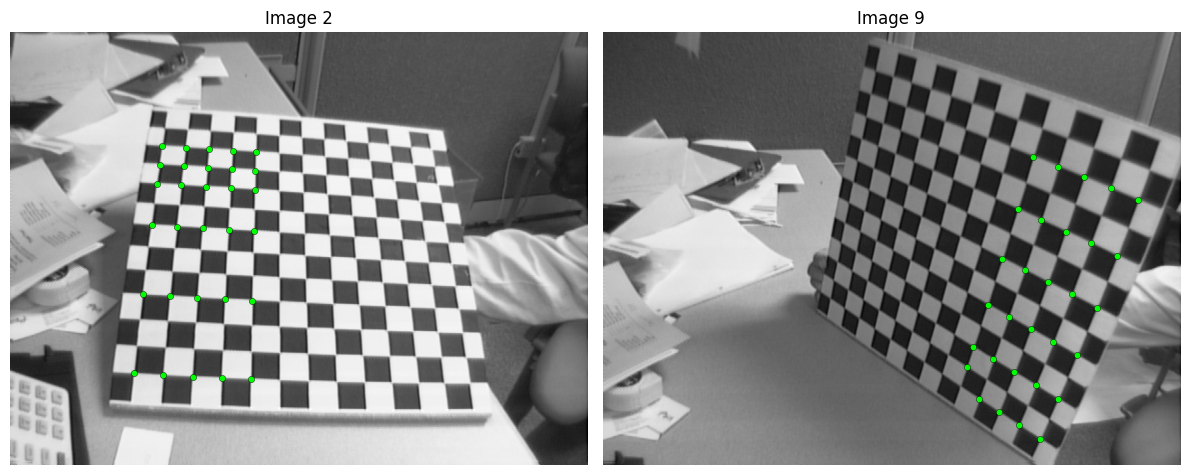

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, img, pts, title in zip(axes, [img2, img9], [pts2, pts9], ['Image 2', 'Image 9']):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.scatter(pts[:, 0], pts[:, 1], s=20, c='lime', edgecolors='k', linewidths=0.3)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()
